In [1]:
from datasets import load_dataset
data_files = {"train": "all_subsets/sampled_train_000000.tar"}

dataset = load_dataset("cubbk/hm_article_sorted_shards_dataset", data_files=data_files)

features_dataset = load_dataset("cubbk/hm_article_sorted_shards_dataset", data_files={"features": "all_subsets/features.json"})

print(dataset)

features = list(features_dataset["features"]["features"][0]) # type: ignore

features

/Users/dan.popa/work/kaggle_getting_started/hm_article_sorter/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['cls', 'jpg', '__key__', '__url__'],
        num_rows: 105100
    })
})


['Accessories',
 'Bags',
 'Cosmetic',
 'Fun',
 'Furniture',
 'Garment Full body',
 'Garment Lower body',
 'Garment Upper body',
 'Garment and Shoe care',
 'Interior textile',
 'Items',
 'Nightwear',
 'Shoes',
 'Socks & Tights',
 'Stationery',
 'Swimwear',
 'Underwear',
 'Underwear/nightwear',
 'Unknown']

In [2]:
model_checkpoint = "facebook/dinov2-base" # pre-trained model from which to fine-tune
batch_size = 144 

In [3]:
# from datasets import load_dataset 

# load a custom dataset from local/remote files or folders using the ImageFolder feature

# option 1: local/remote files
# dataset = load_dataset("jonathan-roberts1/EuroSAT")

# note that you can also provide several splits:
# dataset = load_dataset("imagefolder", data_files={"train": ["path/to/file1", "path/to/file2"], "test": ["path/to/file3", "path/to/file4"]})

# note that you can push your dataset to the hub very easily (and reload afterwards using load_dataset)!
# dataset.push_to_hub("nielsr/eurosat")
# dataset.push_to_hub("nielsr/eurosat", private=True)

# option 2: local folder
# dataset = load_dataset("imagefolder", data_dir="path_to_folder")

# option 3: just load any existing dataset from the hub, like CIFAR-10, FashionMNIST ...
# dataset = load_dataset("cifar10")

In [4]:
import evaluate

metric = evaluate.load("accuracy")



# dataset

# make_smaller = True
# if(make_smaller):
#     # make dataset smaller for quicker training
#     dataset["train"] = dataset["train"].shuffle(seed=42).select(range(1000))



W0825 15:23:07.481000 54244 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [5]:
example = dataset["train"][1] # type: ignore
example


{'cls': 0,
 'jpg': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256>,
 '__key__': '745754001',
 '__url__': '/Users/dan.popa/.cache/huggingface/hub/datasets--cubbk--hm_article_sorted_shards_dataset/snapshots/2ddd7d5a157ba500432fc2e82621fe74743a5383/all_subsets/sampled_train_000000.tar'}

In [6]:
dataset["train"].features # type: ignore

{'cls': Value('int64'),
 'jpg': Image(mode=None, decode=True),
 '__key__': Value('string'),
 '__url__': Value('string')}

In [7]:
labels = features
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = i
    id2label[i] = label

id2label[1]



'Bags'

In [8]:


from transformers import AutoImageProcessor

image_processor  = AutoImageProcessor.from_pretrained(model_checkpoint)
image_processor 



Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


BitImageProcessor {
  "crop_size": {
    "height": 224,
    "width": 224
  },
  "do_center_crop": true,
  "do_convert_rgb": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "BitImageProcessor",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 256
  }
}

In [9]:


from torchvision.transforms import (
    CenterCrop,
    Compose,
    Normalize,
    RandomHorizontalFlip,
    RandomResizedCrop,
    Resize,
    ToTensor,
)

normalize = Normalize(mean=image_processor.image_mean, std=image_processor.image_std)
size = ""
crop_size = ""
if "height" in image_processor.size:
    size = (image_processor.size["height"], image_processor.size["width"])
    crop_size = size
    max_size = None
elif "shortest_edge" in image_processor.size:
    size = image_processor.size["shortest_edge"]
    crop_size = (size, size)
    max_size = image_processor.size.get("longest_edge")

train_transforms = Compose(
        [
            RandomResizedCrop(crop_size),
            RandomHorizontalFlip(),
            ToTensor(),
            normalize,
        ]
    )

val_transforms = Compose(
        [
            Resize(size),
            CenterCrop(crop_size),
            ToTensor(),
            normalize,
        ]
    )

def preprocess_train(example_batch):
    """Apply train_transforms across a batch."""
    example_batch["pixel_values"] = [
        train_transforms(image.convert("RGB")) for image in example_batch["jpg"]
    ]
    return example_batch

def preprocess_val(example_batch):
    """Apply val_transforms across a batch."""
    example_batch["pixel_values"] = [val_transforms(image.convert("RGB")) for image in example_batch["jpg"]]
    return example_batch



In [10]:
# split up training into training + validation
splits = dataset["train"].train_test_split(test_size=0.2, shuffle=True, seed=42) # type: ignore
train_ds = splits['train']
splits_test = splits['test'].train_test_split(test_size=0.5, shuffle=True, seed=42) # type: ignore

val_ds = splits_test['train']

confirm_last = splits_test['test']

In [11]:
train_ds.set_transform(preprocess_train)
val_ds.set_transform(preprocess_val)

In [12]:
train_ds[0]

{'cls': 6,
 'jpg': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256>,
 '__key__': '855255002',
 '__url__': '/Users/dan.popa/.cache/huggingface/hub/datasets--cubbk--hm_article_sorted_shards_dataset/snapshots/2ddd7d5a157ba500432fc2e82621fe74743a5383/all_subsets/sampled_train_000000.tar',
 'pixel_values': tensor([[[1.8722, 1.8722, 1.8722,  ..., 1.8893, 1.8893, 1.8893],
          [1.8722, 1.8722, 1.8722,  ..., 1.8893, 1.8893, 1.8893],
          [1.8722, 1.8722, 1.8722,  ..., 1.8893, 1.8893, 1.8893],
          ...,
          [1.8550, 1.8550, 1.8550,  ..., 1.8208, 1.8208, 1.8208],
          [1.8550, 1.8550, 1.8550,  ..., 1.8208, 1.8208, 1.8208],
          [1.8550, 1.8550, 1.8550,  ..., 1.8208, 1.8208, 1.8208]],
 
         [[2.0259, 2.0259, 2.0259,  ..., 2.0434, 2.0434, 2.0434],
          [2.0259, 2.0259, 2.0259,  ..., 2.0434, 2.0434, 2.0434],
          [2.0259, 2.0259, 2.0259,  ..., 2.0434, 2.0434, 2.0434],
          ...,
          [2.0084, 2.0084, 2.0084,  ..., 1.9734, 1.9734,

In [13]:


from transformers import AutoModelForImageClassification, TrainingArguments, Trainer

model = AutoModelForImageClassification.from_pretrained(
    model_checkpoint, 
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes = True, # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
)



Some weights of Dinov2ForImageClassification were not initialized from the model checkpoint at facebook/dinov2-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [14]:


import os


model_name = model_checkpoint.split("/")[-1]

args = TrainingArguments(
     f"{model_name}-finetuned-clothes-big",
    remove_unused_columns=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=batch_size,
    gradient_accumulation_steps=1,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=3,
    warmup_ratio=0.1,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    bf16=True,
    tf32=True,
    optim="adamw_torch_fused",
    torch_compile=True,
    dataloader_num_workers=min(12, (os.cpu_count() or 12)),  # you have 30GB RAM
    dataloader_pin_memory=True,
    dataloader_persistent_workers=True,
    dataloader_drop_last=True,
    max_grad_norm=0.0,  # disable grad clipping
    push_to_hub=True,
)



ValueError: Your setup doesn't support bf16/gpu.

In [ ]:


import numpy as np

# the compute_metrics function takes a Named Tuple as input:
# predictions, which are the logits of the model as Numpy arrays,
# and label_ids, which are the ground-truth labels as Numpy arrays.
def compute_metrics(eval_pred):
    """Computes accuracy on a batch of predictions"""
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return metric.compute(predictions=predictions, references=eval_pred.label_ids)



In [ ]:
import torch

def collate_fn(examples):
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    labels = torch.tensor([example["cls"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

In [ ]:


trainer = Trainer(
    model,
    args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=image_processor, # type: ignore
    compute_metrics=compute_metrics,
    data_collator=collate_fn,
)



/tmp/ipykernel_4965/1895623272.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
import torch
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass



train_results = trainer.train()
# rest is optional but nice to have
trainer.save_model()
trainer.log_metrics("train", train_results.metrics)
trainer.save_metrics("train", train_results.metrics)
trainer.save_state()



Epoch,Training Loss,Validation Loss,Accuracy
1,0.317600,0.197678,0.937596
2,0.220000,0.155554,0.950521
3,0.176700,0.128885,0.958333


***** train metrics *****
  epoch                    =           3.0
  total_flos               = 23964662462GF
  train_loss               =        0.3157
  train_runtime            =    0:32:26.02
  train_samples_per_second =       129.618
  train_steps_per_second   =         0.899


In [ ]:
metrics = trainer.evaluate()
# some nice to haves:
trainer.log_metrics("eval", metrics)
trainer.save_metrics("eval", metrics)

***** eval metrics *****
  epoch                   =        3.0
  eval_accuracy           =     0.9583
  eval_loss               =     0.1289
  eval_runtime            = 0:00:29.82
  eval_samples_per_second =    352.448
  eval_steps_per_second   =      2.448


INFERENCE

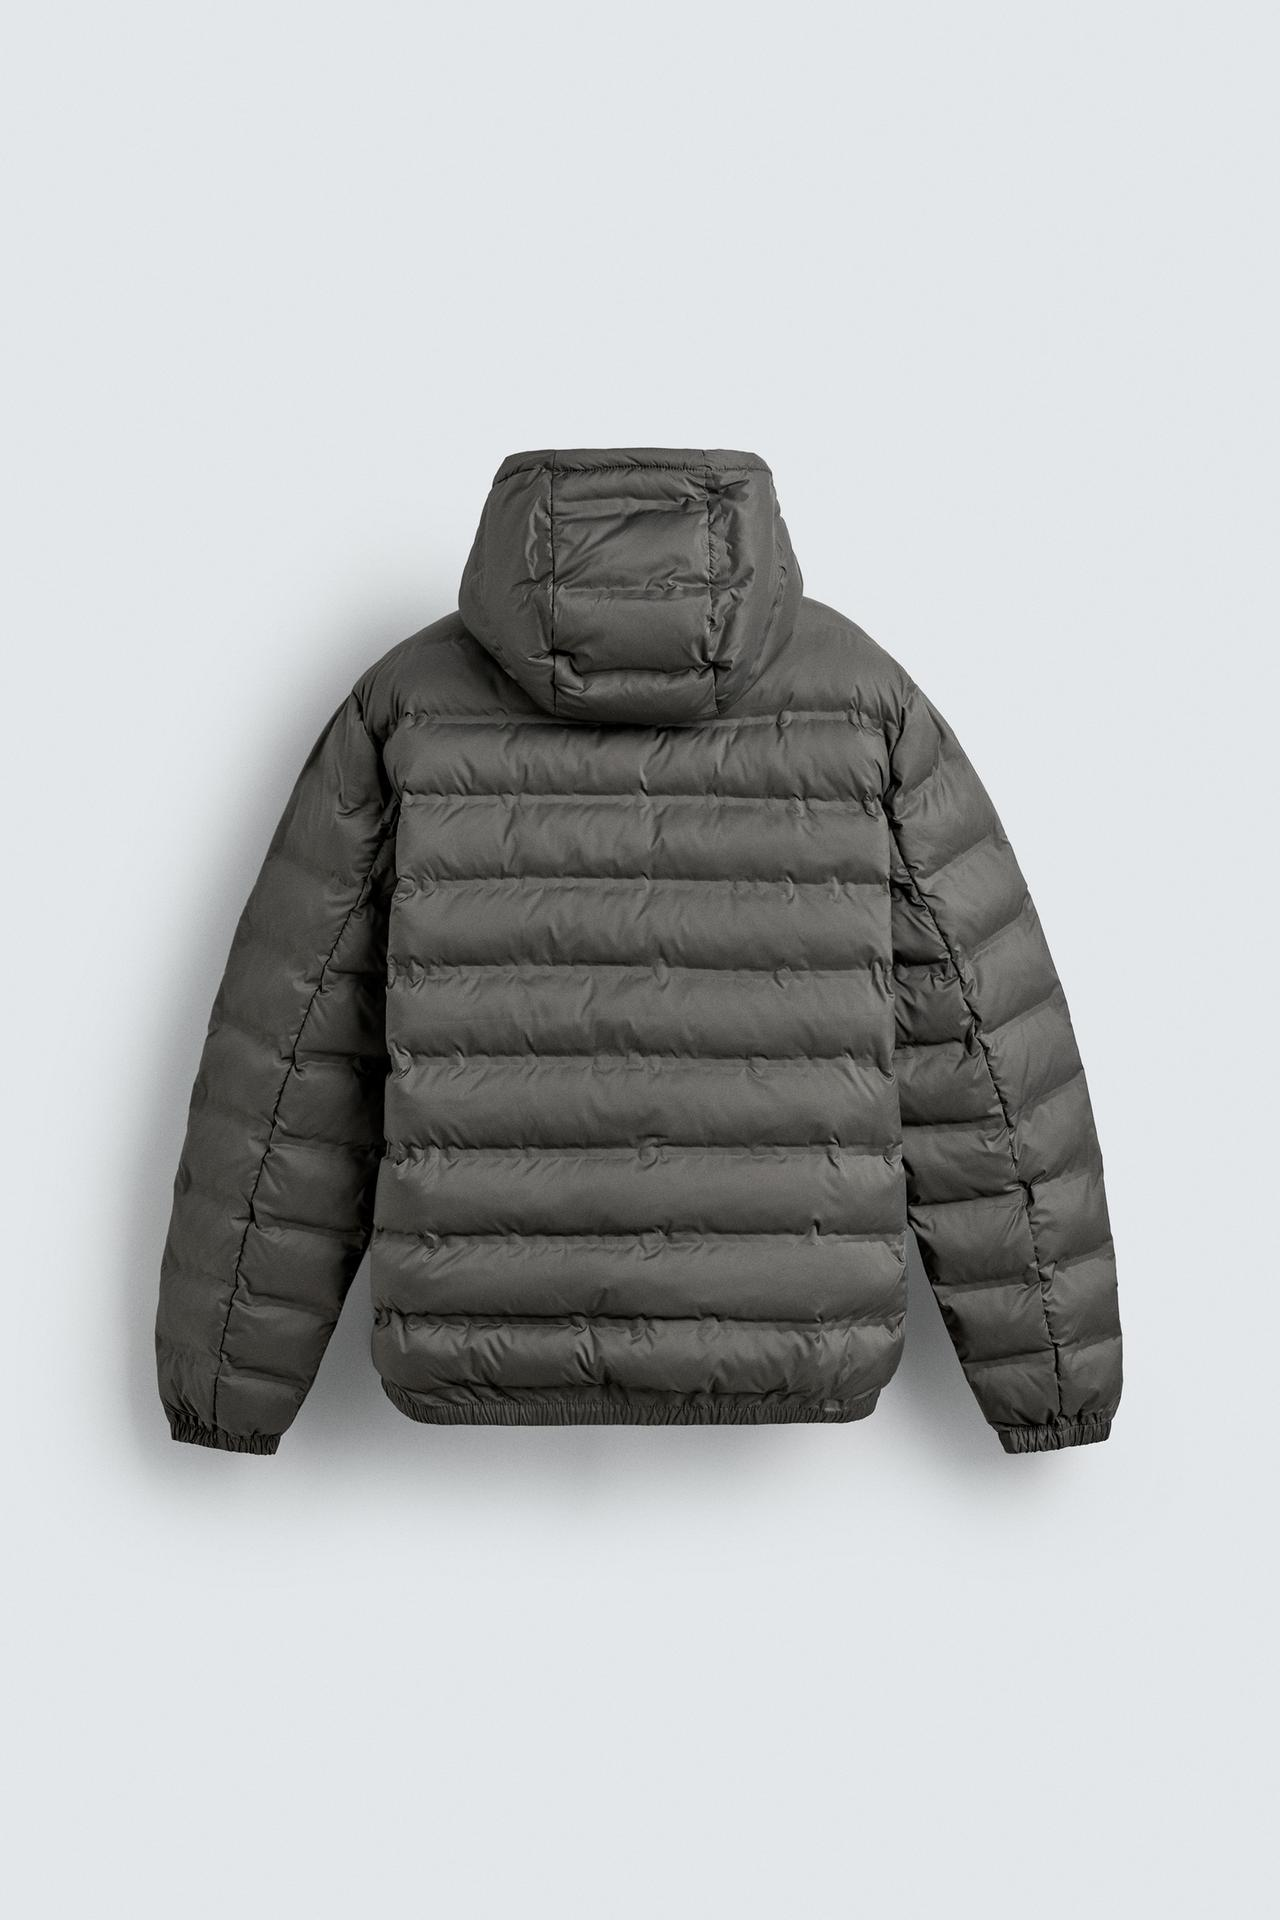

In [ ]:


from PIL import Image
import requests

url = 'https://static.zara.net/assets/public/faa8/0b7b/dc6348e2b336/dc58631e0ded/04695208818-e2/04695208818-e2.jpg?ts=1753797175192&w=1280'
image = Image.open(requests.get(url, stream=True).raw) # type: ignore
image



In [ ]:


from transformers import pipeline

pipe = pipeline("image-classification", "dinov2-base-finetuned-clothes-big")

pipe(image)



Device set to use cuda:0


[{'label': 'Garment Upper body', 'score': 0.9948638081550598},
 {'label': 'Garment Full body', 'score': 0.0042350576259195805},
 {'label': 'Unknown', 'score': 0.0004796560388058424},
 {'label': 'Accessories', 'score': 0.00010893582657445222},
 {'label': 'Underwear', 'score': 0.00010255164670525119}]

In [ ]:


trainer.push_to_hub()



CommitInfo(commit_url='https://huggingface.co/cubbk/dinov2-base-finetuned-clothes-big/commit/b50a34fb42c415ef005e85900edb1287749aba40', commit_message='End of training', commit_description='', oid='b50a34fb42c415ef005e85900edb1287749aba40', pr_url=None, repo_url=RepoUrl('https://huggingface.co/cubbk/dinov2-base-finetuned-clothes-big', endpoint='https://huggingface.co', repo_type='model', repo_id='cubbk/dinov2-base-finetuned-clothes-big'), pr_revision=None, pr_num=None)